   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 11.2 MB/s eta 0:00:00
Mounted at /content/drive
Dataset: Indian Pines
Shape: (145, 145, 200)
Number of classes: 16


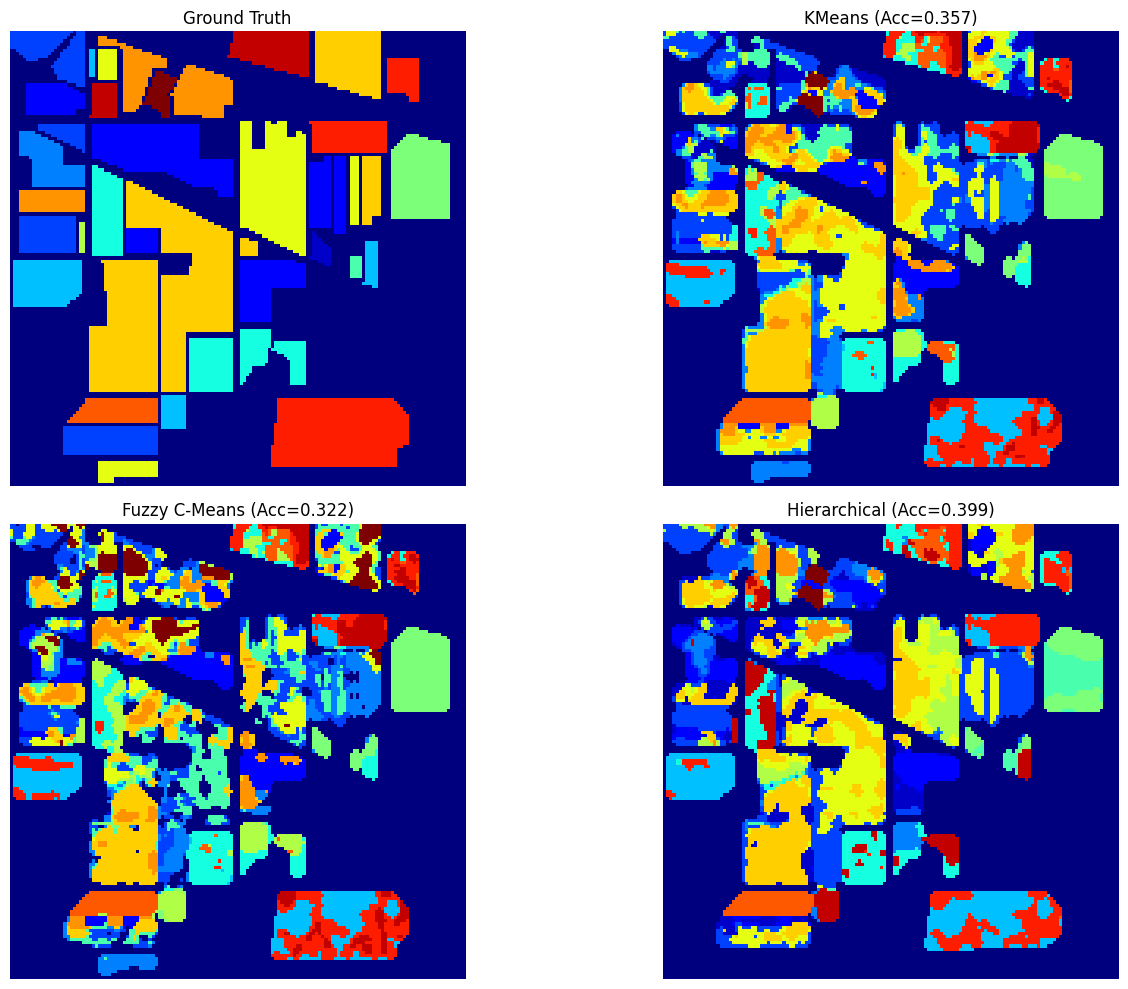


===== FINAL COMPARISON =====
KMeans Accuracy       : 0.3573
Fuzzy C-Means Accuracy: 0.3219
Hierarchical Accuracy : 0.3987


In [ ]:
# ==========================================
# 1. INSTALL + MOUNT DRIVE + IMPORT
# ==========================================
!pip install scikit-fuzzy

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import linear_sum_assignment
from scipy.ndimage import median_filter
import scipy.io
import skfuzzy as fuzz

# ==========================================
# 2. LOAD DATASET FROM GOOGLE DRIVE
# ==========================================
# 👉 UPDATE PATH ACCORDING TO YOUR DRIVE
data_path = "/content/drive/MyDrive/HSI/Indian_pines_corrected.mat"
gt_path   = "/content/drive/MyDrive/HSI/Indian_pines_gt.mat"

data = scipy.io.loadmat(data_path)
gt = scipy.io.loadmat(gt_path)

# Detect dataset
if 'salinas_corrected' in data:
    hsi = data['salinas_corrected']
    ground_truth = gt['salinas_gt']
    print("Dataset: Salinas")
elif 'indian_pines_corrected' in data:
    hsi = data['indian_pines_corrected']
    ground_truth = gt['indian_pines_gt']
    print("Dataset: Indian Pines")
else:
    raise Exception("Unknown dataset format!")

rows, cols, bands = hsi.shape
print("Shape:", hsi.shape)

# ==========================================
# 3. PREPROCESSING (NO PCA)
# ==========================================
X = hsi.reshape(-1, bands)
y = ground_truth.reshape(-1)

# Remove noisy bands (Indian Pines specific)
X = X[:, 20:180]

# Remove background pixels
valid = y > 0
X_valid = X[valid]
y_valid = y[valid]

# Normalize
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_valid)

n_clusters = len(np.unique(y_valid))
print("Number of classes:", n_clusters)

# ==========================================
# 4. LABEL MATCHING (HUNGARIAN)
# ==========================================
def match_labels(true, pred):
    D = max(pred.max(), true.max()) + 1
    w = np.zeros((D, D), dtype=int)

    for i in range(len(pred)):
        w[pred[i], true[i]] += 1

    row_ind, col_ind = linear_sum_assignment(w.max() - w)

    new_pred = np.zeros_like(pred)
    for i in range(len(row_ind)):
        new_pred[pred == row_ind[i]] = col_ind[i]

    return new_pred

# ==========================================
# 5. KMEANS (IMPROVED)
# ==========================================
kmeans = KMeans(
    n_clusters=n_clusters,
    init='k-means++',
    n_init=20,
    max_iter=500,
    random_state=42
)

pred_km = kmeans.fit_predict(X_scaled)
pred_km = match_labels(y_valid, pred_km)
acc_km = accuracy_score(y_valid, pred_km)

# ==========================================
# 6. FUZZY C-MEANS (TUNED)
# ==========================================
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_scaled.T,
    c=n_clusters,
    m=1.8,
    error=0.001,
    maxiter=1500
)

pred_fcm = np.argmax(u, axis=0)
pred_fcm = match_labels(y_valid, pred_fcm)
acc_fcm = accuracy_score(y_valid, pred_fcm)

# ==========================================
# 7. HIERARCHICAL CLUSTERING
# ==========================================
# Subsampling for speed
X_hc = X_scaled[:10000]
y_hc = y_valid[:10000]

hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
pred_hc_small = hc.fit_predict(X_hc)
pred_hc_small = match_labels(y_hc, pred_hc_small)

# Expand predictions
pred_hc = np.zeros_like(y_valid)
pred_hc[:len(pred_hc_small)] = pred_hc_small

acc_hc = accuracy_score(y_valid[:len(pred_hc_small)], pred_hc_small)

# ==========================================
# 8. CREATE MAPS
# ==========================================
def create_map(pred, valid_mask, shape):
    full = np.zeros(shape[0] * shape[1])
    full[valid_mask] = pred
    return full.reshape(shape[0], shape[1])

map_km = create_map(pred_km, valid, (rows, cols))
map_fcm = create_map(pred_fcm, valid, (rows, cols))
map_hc = create_map(pred_hc, valid, (rows, cols))

# ==========================================
# 9. SPATIAL SMOOTHING
# ==========================================
map_km = median_filter(map_km, size=3)
map_fcm = median_filter(map_fcm, size=3)
map_hc = median_filter(map_hc, size=3)

# ==========================================
# 10. VISUALIZATION
# ==========================================
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(ground_truth, cmap='jet')
plt.title("Ground Truth")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(map_km, cmap='jet')
plt.title(f"KMeans (Acc={acc_km:.3f})")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(map_fcm, cmap='jet')
plt.title(f"Fuzzy C-Means (Acc={acc_fcm:.3f})")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(map_hc, cmap='jet')
plt.title(f"Hierarchical (Acc={acc_hc:.3f})")
plt.axis('off')

plt.tight_layout()
plt.show()

# ==========================================
# 11. FINAL RESULTS
# ==========================================
print("\n===== FINAL COMPARISON =====")
print(f"KMeans Accuracy       : {acc_km:.4f}")
print(f"Fuzzy C-Means Accuracy: {acc_fcm:.4f}")
print(f"Hierarchical Accuracy : {acc_hc:.4f}")